In [6]:
# Imports
import os
import sys
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
from typing import List
from sklearn.metrics import mean_squared_error, r2_score, log_loss
from stargazer.stargazer import Stargazer
from IPython.display import display, Latex, HTML
from statsmodels.iolib.summary2 import summary_col
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore") 

In [12]:
data = pd.read_csv("https://osf.io/jvgrf/download")

#-----------------------------------------------------------#
# Sample Selection and Cleaning                             #
# ----------------------------------------------------------#

data["ageyoungestchild"] = np.where(
    data["children"] == 0, None, data["ageyoungestchild"]
)
data["ageyoungestchild"] = pd.to_numeric(data["ageyoungestchild"])

data["ordertaker"] = data["ordertaker"].astype(int)


data["children"] = np.where(data['children']=='yes',1,0)
data["rental"] = np.where(data['rental']=='yes',1,0)
data["bedroom"] = np.where(data['bedroom']=='yes',1,0)

data = data.drop(columns=["phonecalls0"])

ctrl = data.query("treatment == 0")
treatment = data.query("treatment == 1")

## Part 1
#### 1.1

In [14]:
x1 = data['treatment']
x1 = sm.add_constant(x1)
y1 = data['age']
model1 = sm.OLS(y1,x1)
res1 = model1.fit(cov_type="HC0")
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.03814
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.845
Time:                        16:32:09   Log-Likelihood:                -667.95
No. Observations:                 249   AIC:                             1340.
Df Residuals:                     247   BIC:                             1347.
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.3475      0.324     75.119      0.0

The p-value for the regression of age on treatment is the same (at least rounded to 2 decimal places) as listed in the table (theirs = 0.85 vs 0.845 in the regression). 
#### 1.2

In [38]:
def star_from_p(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

def balance_table(df, group_col, variables, decimals=3):
    rows = []

    # split groups
    g0 = df[df[group_col] == 0]
    g1 = df[df[group_col] == 1]

    for v in variables:
        x0 = pd.to_numeric(g0[v], errors="coerce").dropna()
        x1 = pd.to_numeric(g1[v], errors="coerce").dropna()

        mean0, mean1 = x0.mean(), x1.mean()
        sd0, sd1 = x0.std(ddof=1), x1.std(ddof=1)
        n0, n1 = x0.shape[0], x1.shape[0]

        # Welch's t-test (robust to unequal variances)
        tstat, pval = stats.ttest_ind(x1, x0, equal_var=False, nan_policy="omit")

        diff = mean1 - mean0
        stars = star_from_p(pval)

        rows.append({
            "Variable": v,
            "Control mean (sd)": f"{mean0:.{decimals}f} ({sd0:.{decimals}f})",
            "Treated mean (sd)": f"{mean1:.{decimals}f} ({sd1:.{decimals}f})",
            "Diff (T-C)": f"{diff:.{decimals}f}{stars}",
            "p-value": round(pval, decimals)
        })

    out = pd.DataFrame(rows)
    return out

varsToBalance = ['ordertaker', 'perform10', 'prior_experience', 'age',
       'tenure', 'basewage', 'bonus', 'grosswage', 'ageyoungestchild',
       'costofcommute', 'children', 'rental', 'bedroom', 'male', 'married',
       'second_technical', 'high_school', 'tertiary_technical', 'university',
       'internet']
bt = balance_table(data, "treatment", varsToBalance, decimals=3)

# Print nicely (console)
print("\nBALANCE TABLE (Control vs Treated)")
print(bt.to_string(index=False))


BALANCE TABLE (Control vs Treated)
          Variable  Control mean (sd)  Treated mean (sd) Diff (T-C)  p-value
        ordertaker      0.559 (0.499)      0.519 (0.502)     -0.040    0.527
         perform10     -0.040 (0.540)     -0.028 (0.619)      0.012    0.874
  prior_experience    16.753 (23.818)    18.962 (27.658)      2.209    0.499
               age     24.347 (3.536)     24.435 (3.567)      0.088    0.846
            tenure    28.254 (21.938)    26.137 (21.942)     -2.117    0.448
          basewage 1562.799 (185.397) 1539.864 (136.157)    -22.935    0.272
             bonus 1092.587 (655.717) 1030.902 (597.664)    -61.685    0.440
         grosswage 3003.362 (825.599) 2949.730 (758.050)    -53.632    0.595
  ageyoungestchild      0.712 (1.922)      0.527 (1.939)     -0.185    0.450
     costofcommute      8.338 (5.554)      7.892 (8.031)     -0.446    0.608
          children      0.237 (0.427)      0.115 (0.320)   -0.123**    0.012
            rental      0.203 (0.404)   

#### 1.3
Based on the balance table, for the vast majority of the variables shown, there is no statistically significant difference between the control and treatment groups. There are two exceptions. The Children variable is significant at 95% confidence. and the Married variable is significant at 90% confidence. 
## Part 2
#### 2.1

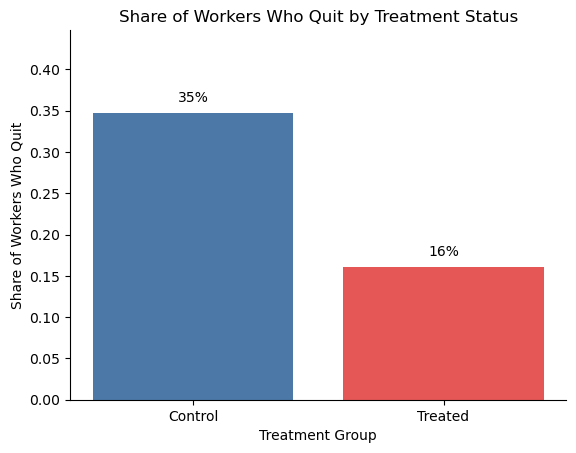

In [26]:
quitJob = (
    data.groupby("treatment", as_index=False)["quitjob"]
        .mean()
        .rename(columns={"quitjob": "percentQuit"})
)
order = ["Control", "Treated"]
quitJob['treatment'] = order

quitJob["treatment"] = pd.Categorical(quitJob["treatment"], categories=order, ordered=True)
quitJob = quitJob.sort_values("treatment")

# Plot
colors = {"Control": "#4C78A8", "Treated": "#E45756"}

fig, ax = plt.subplots()

bars = ax.bar(
    quitJob["treatment"].astype(str),
    quitJob["percentQuit"],
    color=[colors[g] for g in quitJob["treatment"].astype(str)]
)

# If you want to get fancy, sdd labels above bars (percent)
for b, val in zip(bars, quitJob["percentQuit"]):
    ax.text(
        b.get_x() + b.get_width() / 2,
        val + 0.01,
        f"{val:.0%}",
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Treatment Group")
ax.set_ylabel("Share of Workers Who Quit")
ax.set_title("Share of Workers Who Quit by Treatment Status")

# Make it look clean (similar to theme_minimal)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.ylim(0, max(quitJob["percentQuit"]) + 0.10)
plt.show()

#### 2.2
Based on the bar graph, a smaller proportion of workers who were in the treatment group quit during this interval compared to those in the control group. Only 16% of workers who worked from home quit, compared to 35% of those who worked from the office during this period. 
## Part 3
#### 3.1

In [ ]:
x2 = data.loc[:,['treatment']]
x2 = sm.add_constant(x2)
y2 = data['quitjob']
model2 = sm.OLS(y2,x2)
res2 = model2.fit(cov_type="HC0")

x3 = data.loc[data['ordertaker']==1,['treatment']]
x3 = sm.add_constant(x3)
y3 = data.loc[data['ordertaker']==1,['phonecalls1']]
model3 = sm.OLS(y3,x3)
res3 = model3.fit(cov_type="HC0")

x4 = data.loc[:,['treatment','married','children']]
x4 = sm.add_constant(x4)
y4 = data['quitjob']
model4 = sm.OLS(y4,x4)
res4 = model4.fit(cov_type="HC0")

x5 = data.loc[data['ordertaker']==1,['treatment','married','children']]
x5 = sm.add_constant(x5)
y5 = data.loc[data['ordertaker']==1,['phonecalls1']]
model5 = sm.OLS(y5,x5)
res5 = model5.fit(cov_type="HC0")

varNames = {'treatment': "Treatment",'married':"Married",'children':"Children",'const':"Const"}

stargazer = Stargazer([res2, res3, res4, res5])
stargazer.covariate_order(['treatment','married','children','const'])
stargazer.rename_covariates(varNames)
stargazer.custom_columns(['Model 1','Model 2','Model 3', 'Model 4'])
display(HTML(stargazer.render_html()))

#### 3.2
Model 1 suggests that working from home is, on average, associated with a 18.7% lower likelihood of quiting, significant at 99%. The same is true of model 3, except it adds that being married corresponds to a 12.9% lower chance of quitting (significant at 90%) and having children is not significant. The results of Model 2 suggest that working from home is associated with making an average of 4039 more calls than those that work from the office. The coefficient on treatment in Model 4 is slightly different, with an average of 4056 more calls in the treatment group. Being married is associated with an average of 5439 fewer calls, significant at 95%, while the children variable is again statistically insignificant. 

In [39]:
x6 = data.loc[:,['treatment']+varsToBalance]
x6 = sm.add_constant(x6)
y6 = data['quitjob']
model6 = sm.OLS(y6,x6)
res6 = model6.fit(cov_type="HC0")

x7 = data.loc[data['ordertaker']==1,['treatment']+varsToBalance]
x7 = sm.add_constant(x7)
y7 = data.loc[data['ordertaker']==1,['phonecalls1']]
model7 = sm.OLS(y7,x7)
res7 = model7.fit(cov_type="HC0")

stargazer2 = Stargazer([res4, res5, res6, res7])
stargazer2.covariate_order(['treatment']+varsToBalance+['const'])
stargazer2.custom_columns(['Model 3','Model 4','Model 5', 'Model 6'])
display(HTML(stargazer2.render_html()))

Yes, adding the controls does change the results slightly. The difference in the likelihood of quitting between the control and treatment groups goes from 18.7% less likely to 17.7% less likely. The average greater number of calls in the treatment group also declines from 4056 to 3708. Finally, several of the control variables prove to be statustically significant in their effects on the dependent variables. The cost of commute and one of the education variables has a statustically significant effect on the likelihood of quitting. In Model 6, base and gross wages, being married, 3 of the education variables, and having internet access have a statustically significant effect on the call volume. 
#### 3.3

In [52]:
x8 = data.loc[:,['treatment','age','male','married','costofcommute']]
x8 = sm.add_constant(x8)
y8 = data['quitjob']
model8 = sm.OLS(y8,x8)
res8 = model8.fit(cov_type="HC0")

model9 = sm.Probit(y8,x8)
res9 = model9.fit(cov_type="HC0")
effect9 = res9.get_margeff()

res10 = sm.Probit(y8,x8).fit(cov_type="HC0")

effect9 = effect9.summary_frame()
res10.params.update(effect9["dy/dx"])
res10.bse.update(effect9["Std. Err."])

stargazer3 = Stargazer([res8,res9,res10])
stargazer3.covariate_order(['treatment','age','male','married', 'costofcommute','const'])
stargazer3.custom_columns(['LPM','Probit','Probit (Marginal Effects)'])
stargazer3.dependent_variable_name('Likelihood of Quitting')
display(HTML(stargazer3.render_html()))

Optimization terminated successfully.
         Current function value: 0.509501
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.509501
         Iterations 6


In [48]:
data['pred_lpm'] = res8.predict(x8)
data['pred_probit'] = res9.predict(x8)

preds = {
    "LPM": data["pred_lpm"].astype(float),
    "Probit": data["pred_probit"].astype(float),
}

eps = 1e-15
preds_clip = {k: v.clip(eps, 1 - eps) for k, v in preds.items()}
y = data["quitjob"].astype(float)

metrics = pd.DataFrame(
    {
        "Brier-score": {k: mean_squared_error(y, v) for k, v in preds.items()},
    }
).T.round(5)
metrics

,LPM,Probit
Brier-score,0.16905,0.16898


Both the LPM coefficients and marginal effects on the Probit model show very similar results to two decimal places for all of the variables. The results also generally concur with Table VIII in the paper. For the Brier score, the Probit model has a slightly better Brier score, being lower by just 0.00007 compared to the LPM model. 
#### 3.4
Both the LPM and Probit models have treatment showing a statistically significant effect on quitting, with workers who work from home being, on average, 17.8% (17.6% in Probit) less likely to quit. Age is also significant in both models, with each additional year corresponding to an average of 2.4% (2.6%) lower likelihood of quitting. The only other variable that is statisically significant, albeit at a lower confidence level, is cost of commute. Finally, gender or marital status appears to not have a statistically significant effect on the likelihood of quitting in either model. 